In [1]:
import pandas as pd
import numpy as np
import matplotlib.pylab as plt
import h5py
import sys
sys.path.append("../src")
import numpy as np
import pandas as pd
import torch
import matplotlib.pylab as plt
# from synthetic_observations import Observations
from realstar_synthetic_observations import Observations

from transformer import *
from spectrum_lsf import Score_Likelihood
from score_models import ScoreModel
device  = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
from template import Template
from sbart_rv_finder import RV_Retrieval
from mala import MALA
from matplotlib import gridspec



In [6]:
df = pd.read_pickle("../data/training_data/SPIRou46_train.df")
a = df[(df['teff']==3200)&(df['logg']==5.0)&(df['metal']==-0.5)]
# a = df[(df['teff']==2900)&(df['logg']==5.0)&(df['metal']==0.0)]

In [7]:
a['Final'].iloc[0][10:30]

array([1.0968892 , 1.09799419, 1.09841242, 1.09848717, 1.09836627,
       1.09812022, 1.09780571, 1.09749029, 1.09725184, 1.09716346,
       1.09727195, 1.09757742, 1.09801982, 1.098476  , 1.09876766,
       1.09867722, 1.09796769, 1.09640286, 1.09376744, 1.08988955])

In [8]:
a['Broadened'].iloc[0].shape

(18592,)

In [5]:
a['Normalized'].iloc[0][0:13]

array([1.16305479, 1.16223399, 1.15781432, 1.15068425, 1.14265137,
       1.13548579, 1.13015328, 1.12674129, 1.1249206 , 1.12448635,
       1.12549952, 1.12783778, 1.13072667])

1 6490751.076153424 934576.1641438127
2 0.7160778330785487 0.11654698136360846
3 0.8962064054557844 0.11494879662774453
4 0.981362188120476 0.048004212118866026
12 6.4036270986111345 -0.6009553639536016
20 1.398797831109141 -0.0732561834802008


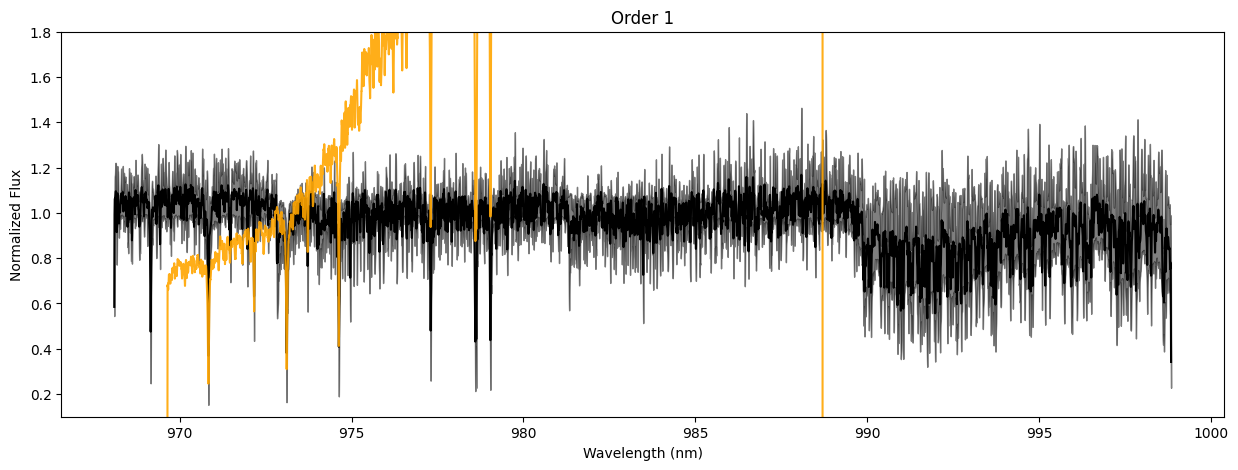

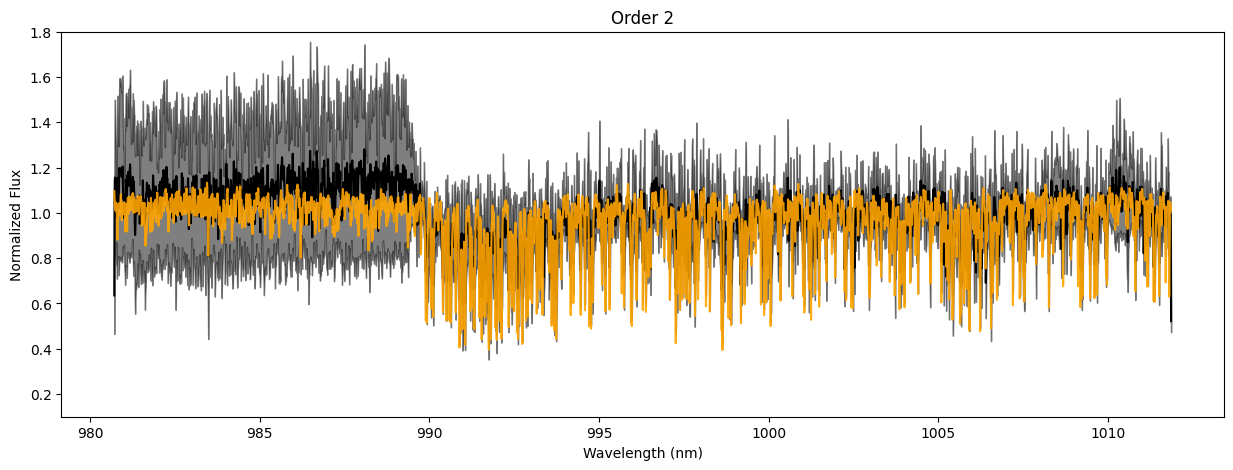

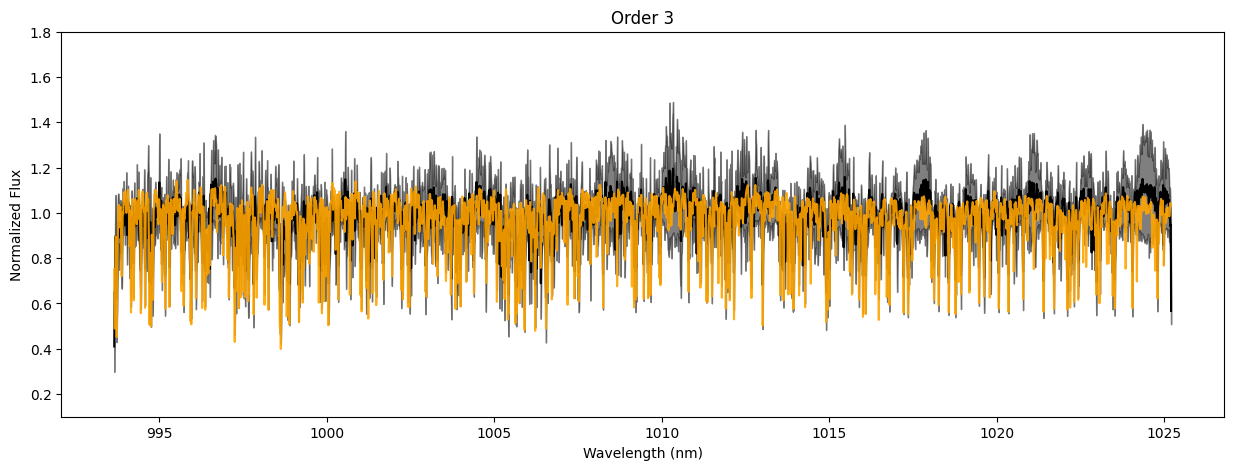

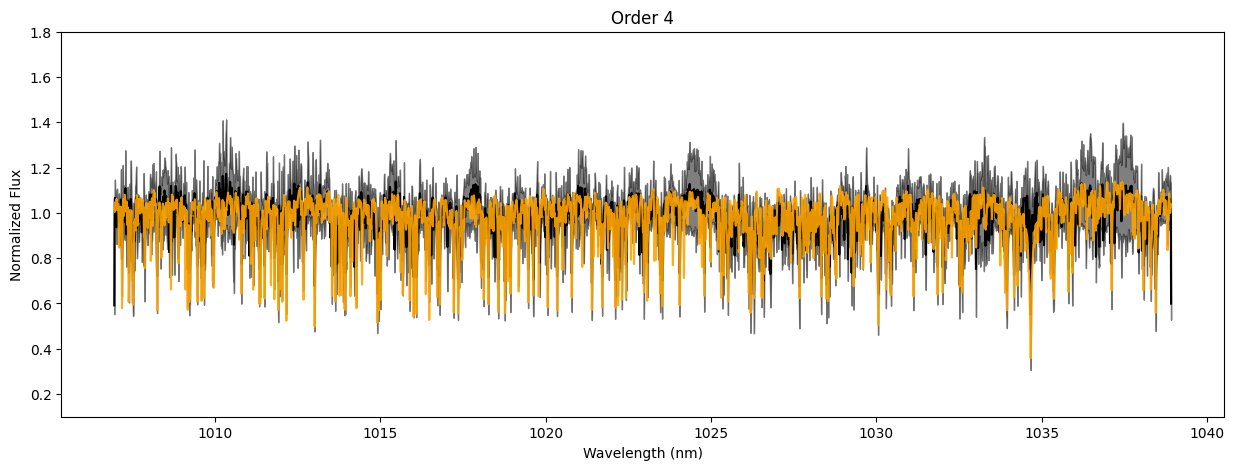

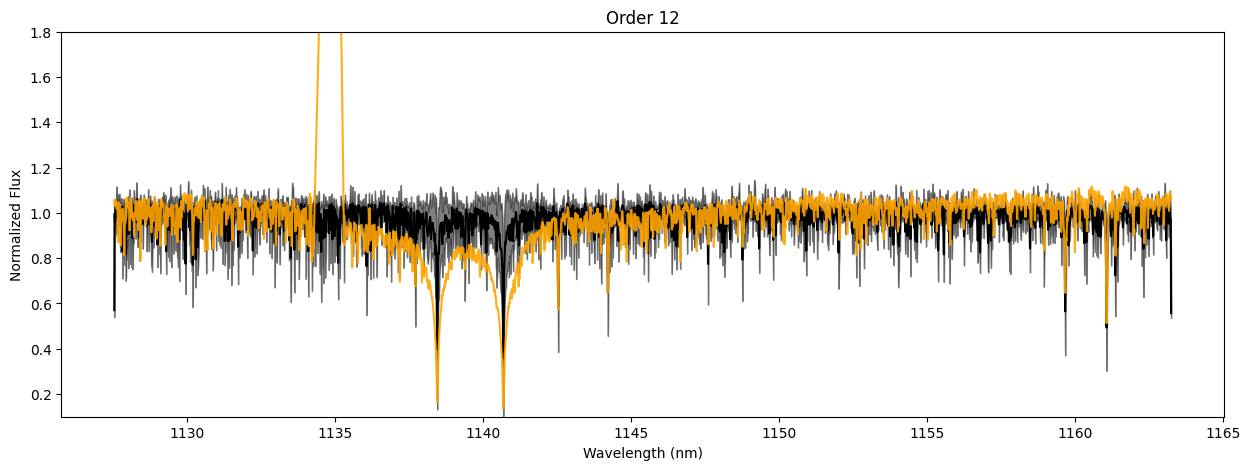

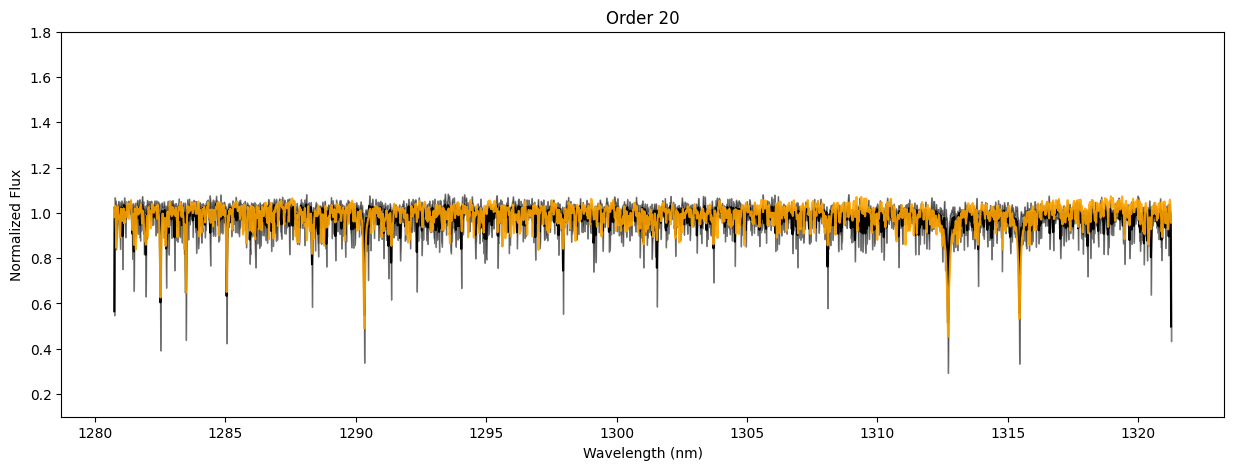

In [2]:
orders = [0,46]

for o in orders:
    if o<10:
        df = pd.read_pickle("../data/training_data/SPIRou0"+str(o)+"_train.df")
    else:
        df = pd.read_pickle("../data/training_data/SPIRou"+str(o)+"_train.df")
    non_ones = np.where(df['Wavelength'].iloc[0] != 1)[0]
    flux = np.vstack(df['Final'].to_numpy())
    flux = flux[:,non_ones]
    mean, std = np.mean(flux,axis=0), np.std(flux,axis=0)
    df = []
    if o<10:
        obs = Observations(i=0,N=1,order=o,filepath="../data/validation_data/SPIRou0"+str(o)+"_val.df",star='barnards')
    else:
        obs = Observations(i=0,N=1,order=o,filepath="../data/validation_data/SPIRou"+str(o)+"_val.df",star='barnards')
    
    zscore_p = (mean - np.array(obs.original_spectrum[0,0])) / std
    print(o,np.std(zscore_p), np.mean(zscore_p))
    plt.figure(figsize=(15,5))

    plt.plot(obs.wgrid,mean,c="k")
    plt.fill_between(obs.wgrid,mean-std,mean+std,color="k",alpha=0.5)

    plt.plot(obs.wgrid,obs.original_spectrum[0,0],"orange",alpha=0.9,label="PROXIMA")
    if torch.isnan(obs.original_spectrum[0,0]).any():
        print("There is at least one NaN in the tensor!")
    # plt.xlim(1525,1530)
    plt.ylim(0.1,1.8)
    plt.xlabel("Wavelength (nm)")
    plt.ylabel("Normalized Flux")
    plt.title("Order "+str(o))